# Solver Westervelt: explicite et semi-implicite

Ce notebook presente la formulation a variable auxiliaire du modele de Westervelt, puis montre:
- une simulation 1D,
- des snapshots temporels,
- l'evolution de l'energie,
- une mini etude de stabilite numerique.


## Equation continue et schemas discrets

On considere:
$$
(1-2ku)u_{tt} - c^2 u_{xx} - b u_{xxt} = 2k(u_t)^2.
$$

Variable auxiliaire:
$$
F(u) = (1-2ku)u_t - b u_{xx}.
$$

Schema explicite:
$$
\begin{cases}
F_i^{n+1}=F_i^n+\Delta t\left(c^2\delta_{xx}u_i^n+2k\left(D_t^-u_i^n\right)^2\right),\\
 u_i^{n+1}=u_i^n+\Delta t\,\dfrac{F_i^{n+1}+b\,\delta_{xx}u_i^n}{1-2ku_i^n}.
\end{cases}
$$

Schema semi-implicite:
$$
\begin{cases}
F_i^{n+1}=F_i^n+\Delta t\left(c^2\delta_{xx}u_i^n+2k\left(D_t^-u_i^n\right)^2\right),\\
 u_i^{n+1}=u_i^n+\Delta t\,\dfrac{F_i^{n+1}+b\,\delta_{xx}u_i^{n+1}}{1-2ku_i^n}.
\end{cases}
$$


In [1]:
from src.solver import WesterveltSolver, WesterveltParams
from src.postprocessing import plot_stability_scan


## Configuration de la simulation


In [28]:
params = WesterveltParams(
    c=1500,
    rho0=1000,
    nu=0.01,
    beta=4.8,
    mu_v=1e-3,
    dx=1e-4,
    dt=2e-8,
    nx=1200,
    nt=1200,
    scheme="explicit",
    bc="dirichlet"
)

solver = WesterveltSolver(params)
solver.initialize(ic_type="gaussian")


Indicateurs: lambda=4.5e+06, cfl=0.3
Attention: lambda > 0.5 en explicite (risque d'instabilité théorique).


## Snapshots de la solution


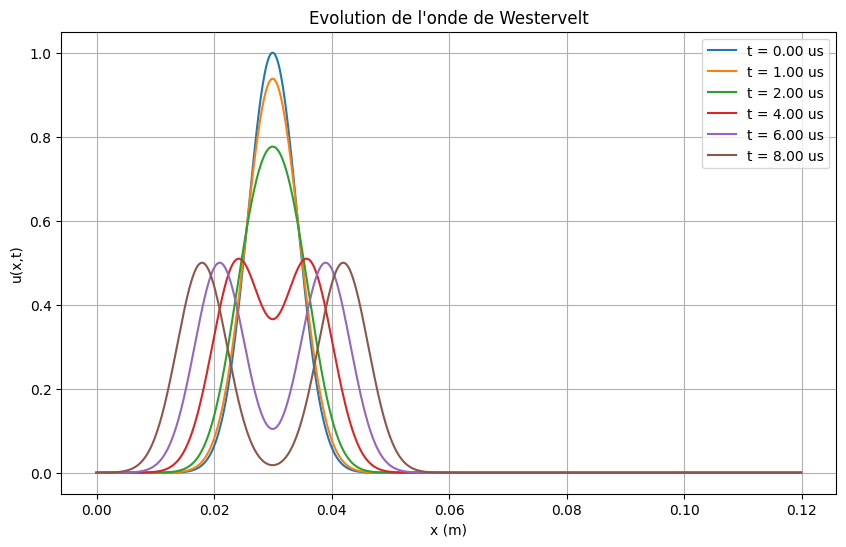

In [29]:
times = [0.0, 1e-6, 2e-6, 4e-6, 6e-6, 8e-6]
snapshots = solver.run_with_snapshots(times, store_energy=True)
solver.plot_snapshots(snapshots)


## Graphe d'energie


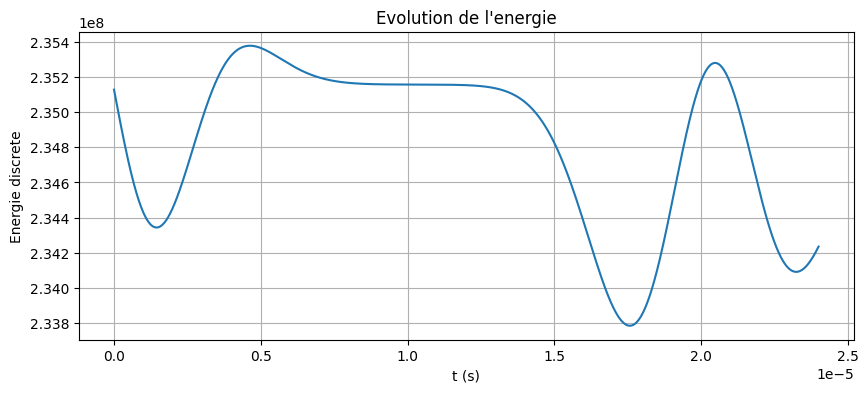

In [31]:
solver.plot_energy()


## Mini etude de stabilite

On balaye quelques valeurs de $\Delta t$ et d'amplitude initiale,
puis on visualise une carte stable/instable.


Indicateurs: lambda=2.7e+06, cfl=0.18
Attention: lambda > 0.5 en explicite (risque d'instabilité théorique).
Indicateurs: lambda=2.7e+06, cfl=0.18
Attention: lambda > 0.5 en explicite (risque d'instabilité théorique).
Indicateurs: lambda=2.7e+06, cfl=0.18
Attention: lambda > 0.5 en explicite (risque d'instabilité théorique).
Indicateurs: lambda=2.7e+06, cfl=0.18
Attention: lambda > 0.5 en explicite (risque d'instabilité théorique).
Indicateurs: lambda=2.7e+06, cfl=0.18
Attention: lambda > 0.5 en explicite (risque d'instabilité théorique).
Indicateurs: lambda=2.7e+06, cfl=0.18
Attention: lambda > 0.5 en explicite (risque d'instabilité théorique).
Indicateurs: lambda=4.05e+06, cfl=0.27
Attention: lambda > 0.5 en explicite (risque d'instabilité théorique).
Indicateurs: lambda=4.05e+06, cfl=0.27
Attention: lambda > 0.5 en explicite (risque d'instabilité théorique).
Indicateurs: lambda=4.05e+06, cfl=0.27
Attention: lambda > 0.5 en explicite (risque d'instabilité théorique).
Indicateurs: lam

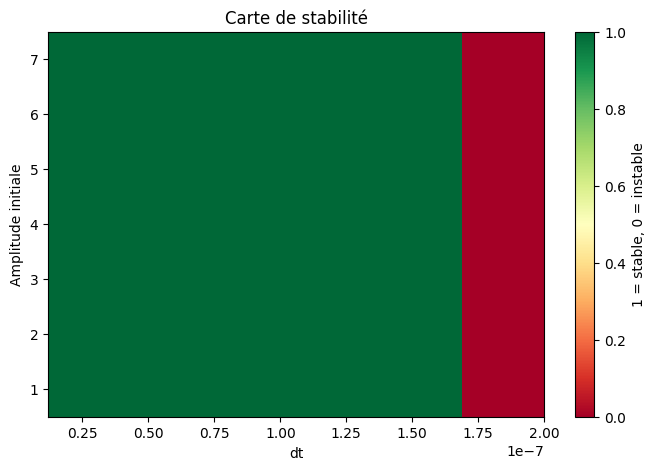

In [32]:
dt_values = [1.2e-8, 1.8e-8, 2.5e-8, 3.0e-8, 4.5e-8, 2.0e-7]
amp_values = [0.5, 1.0, 1.5, 2.0, 2.5, 7.5]

stability = solver.run_stability_scan(
    dt_values=dt_values,
    amplitude_values=amp_values,
    blowup_threshold=1e5,
)

stable_count = sum(1 for r in stability if r["stable"])
print(f"Configurations stables: {stable_count}/{len(stability)}")
plot_stability_scan(stability)


## Notes

- Pour comparer les deux schemas, utiliser `scheme="explicit"` puis `scheme="semi_implicit"`.
- Pour reduire le temps de calcul, diminuer `nx` et `nt`.
- Le critere principal de stabilite est base sur lambda; CFL est un indicateur complementaire.
